In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
# Sample Advertising dataset
data = pd.DataFrame({
    'TV': [230.1, 44.5, 17.2, 151.5, 180.8, 8.7, 57.5, 120.2, 8.6, 199.8],
    'Radio': [37.8, 39.3, 45.9, 41.3, 10.8, 48.9, 32.8, 19.6, 2.1, 2.6],
    'Newspaper': [69.2, 45.1, 69.3, 58.5, 58.4, 75.0, 23.5, 11.6, 1.0, 21.2],
    'Sales': [22.1, 10.4, 9.3, 18.5, 12.9, 7.2, 11.8, 13.2, 4.8, 15.6]
})

print("✅ Dataset Loaded Successfully!")
print(data.head())


✅ Dataset Loaded Successfully!
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         10 non-null     float64
 1   Radio      10 non-null     float64
 2   Newspaper  10 non-null     float64
 3   Sales      10 non-null     float64
dtypes: float64(4)
memory usage: 452.0 bytes
None

Summary Statistics:
              TV      Radio  Newspaper      Sales
count   10.00000  10.000000  10.000000  10.000000
mean   101.89000  28.110000  43.280000  12.580000
std     84.89945  17.836071  26.850649   5.173393
min      8.60000   2.100000   1.000000   4.800000
25%     24.02500  13.000000  21.775000   9.575000
50%     88.85000  35.300000  51.750000  12.350000
75%    173.47500  40.800000  66.525000  15.000000
max    230.10000  48.900000  75.000000  22.100000


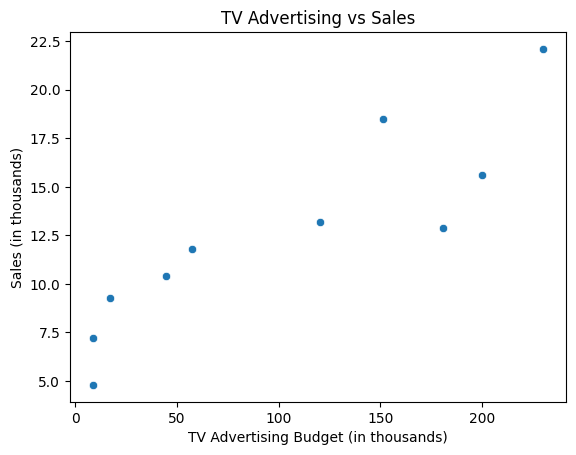

In [4]:
print("\nDataset Info:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe())

# Visualize relationship between TV and Sales
sns.scatterplot(x='TV', y='Sales', data=data)
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget (in thousands)")
plt.ylabel("Sales (in thousands)")
plt.show()


In [5]:
# Independent and dependent variables
X = data[['TV']]   # Feature
y = data['Sales']  # Target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])


✅ Model trained successfully!
Intercept: 7.85899138140106
Coefficient: 0.04941817037563835



📊 Model Performance:
Mean Absolute Error: 1.91
Mean Squared Error: 6.13
R² Score: 0.22


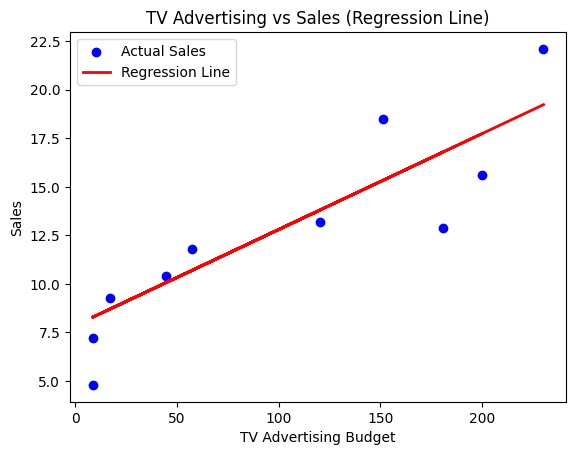

In [7]:
# Predict on test data
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 Model Performance:")
print("Mean Absolute Error:", round(mae, 2))
print("Mean Squared Error:", round(mse, 2))
print("R² Score:", round(r2, 2))

# Plot regression line
plt.scatter(X, y, color='blue', label='Actual Sales')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.title("TV Advertising vs Sales (Regression Line)")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.legend()
plt.show()


In [8]:
# Example: Predict sales when TV ad spend = 200
new_tv_budget = 200
predicted_sales = model.predict([[new_tv_budget]])[0]

print(f"\n💰 Predicted Sales for TV Budget of {new_tv_budget}k: {predicted_sales:.2f} units")



💰 Predicted Sales for TV Budget of 200k: 17.74 units


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
